In [29]:
import matplotlib.colors as mplcol
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
from mienc import Corrector

/home/raffaelli/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


In [18]:
filename = "/mnt/DATA/Motion_fMRI/Datasets/eso245/eso245_aal_strin_90.mat"
mat = loadmat(filename)["subj_tcs"]
step_num, reg_num, subj_num = mat.shape

name = filename.split("_")[1]
reg_pair = int(reg_num*(reg_num-1)/2)

num_mats = 20
block_size = int(step_num/num_mats)
corr1 = np.empty((num_mats,reg_pair,subj_num))
for i in np.arange(num_mats):
    for j in range(subj_num):
        corr1[i,:,j] = np.corrcoef(mat[block_size*i:block_size*(i+1),:,j], rowvar=False)[np.triu_indices(reg_num,1)]

corr2 = np.zeros((num_mats,num_mats,subj_num))
for i in range(subj_num):
    tmp = np.corrcoef(corr1[:,:,i], rowvar=True)
    np.fill_diagonal(tmp, np.nan)
    corr2[:,:,i] = tmp[:,:]


fMRI/Datasets/eso245/eso245


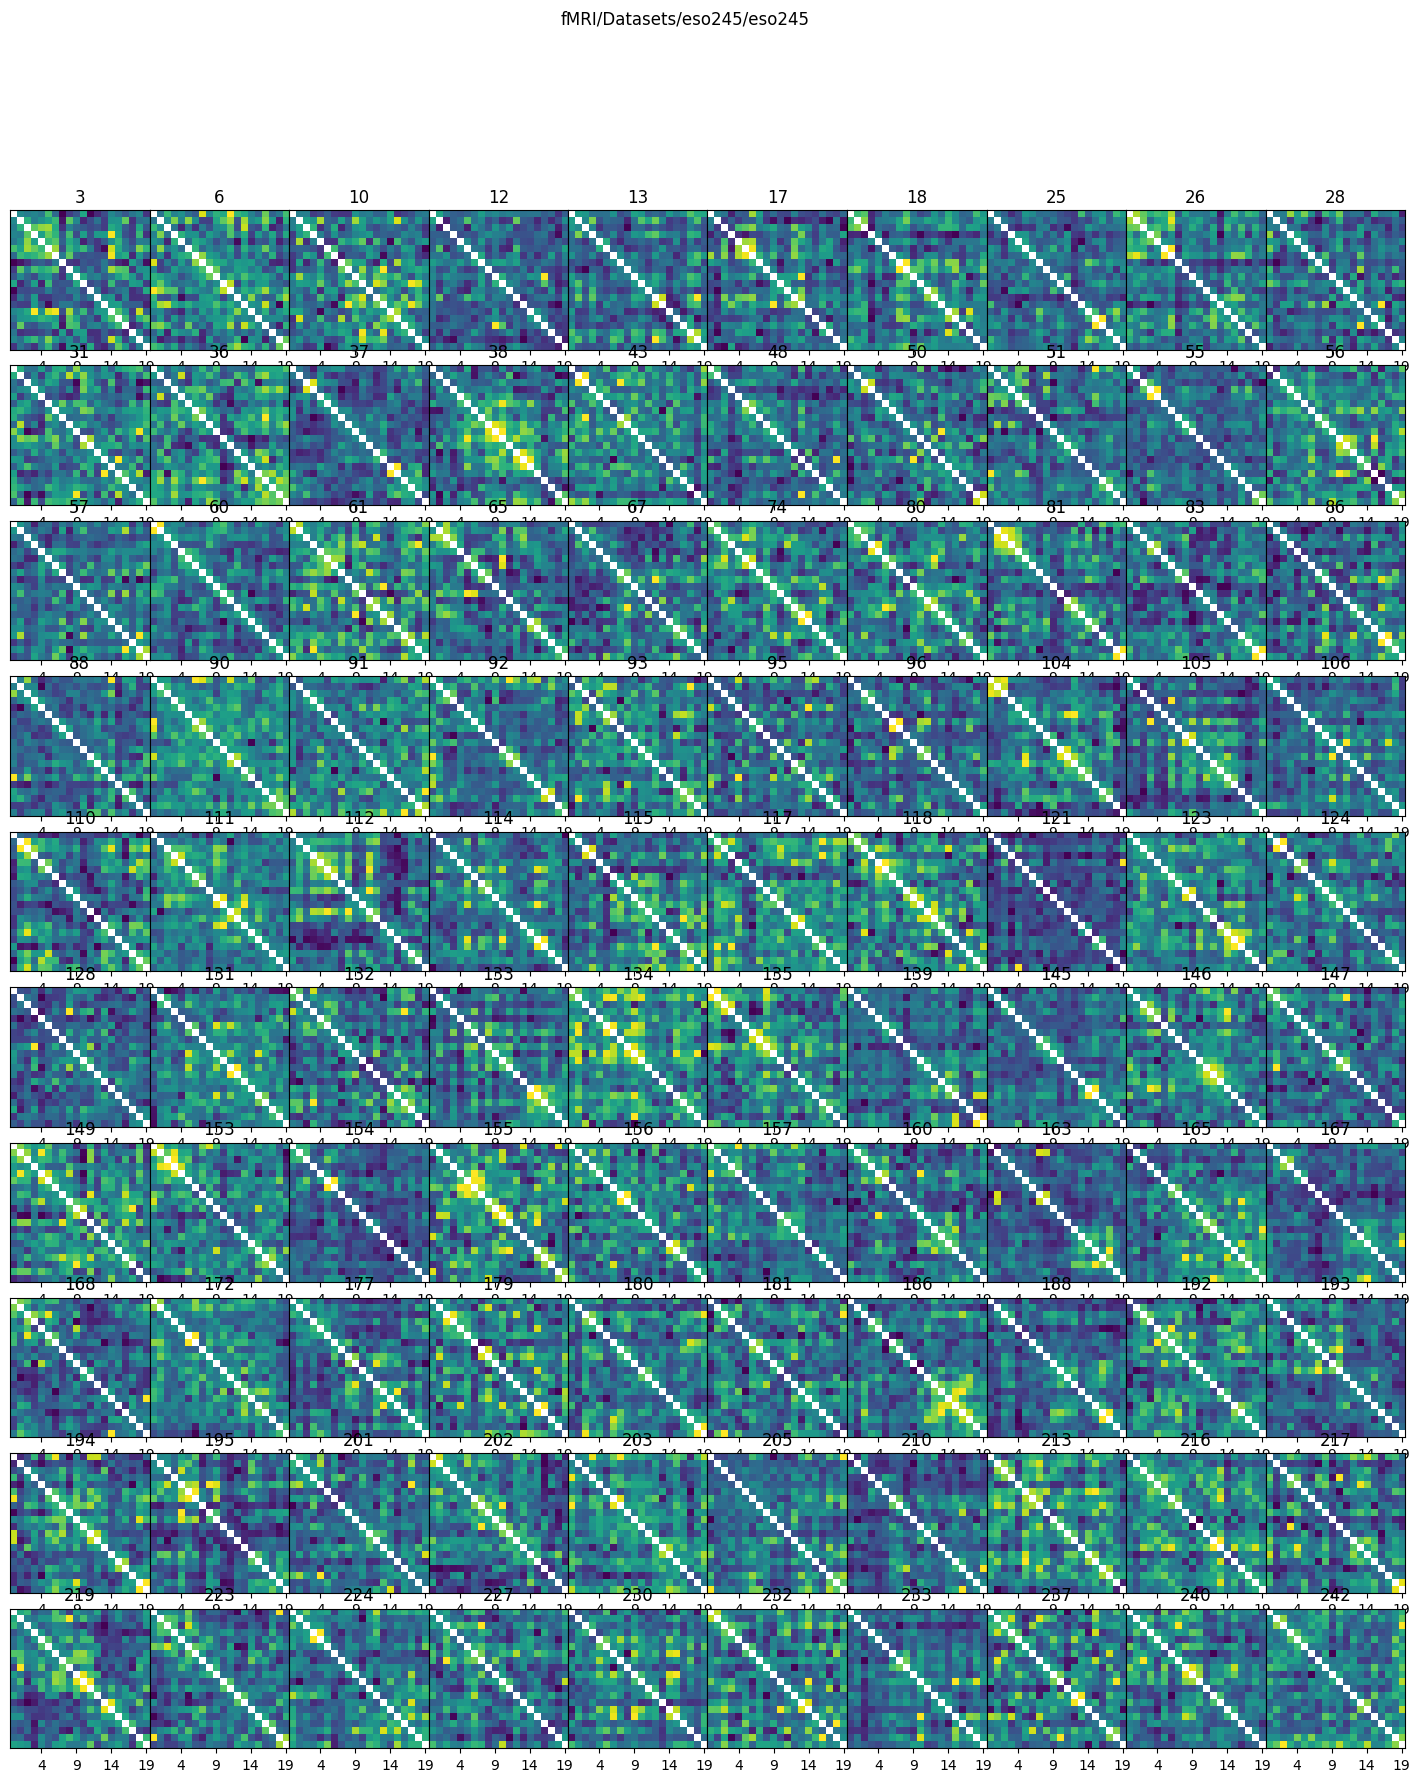

In [22]:

fig, ax = plt.subplots(10,10, figsize=(18,20))
for i, subj in enumerate(sorted(np.random.choice(245,100,False))):
    plt.sca(ax[i//10,i%10])
    plt.imshow(corr2[:,:,subj])
    # plt.colorbar(shrink=0.8)
    plt.xticks(np.array([5,10,15,20])-1)
    plt.yticks([])
    plt.title(subj)
plt.suptitle(name)
print(name)
plt.subplots_adjust(wspace=0, hspace=0.1)
plt.show()

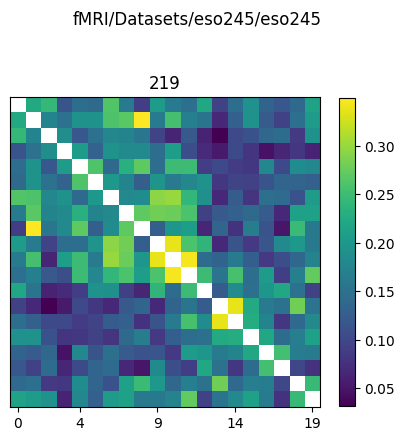

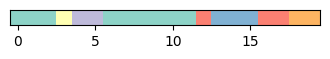

In [28]:
TL=219
int_corr = corr2[:,:,TL]

fig, ax = plt.subplots(1,1, figsize=(5,5))
plt.sca(ax)
plt.imshow(int_corr[:,:])
plt.colorbar(shrink=0.8)
plt.title(TL)
plt.xticks(np.array([1, 5,10,15,20])-1)
plt.yticks([])
plt.suptitle(name)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

corr_plt = (int_corr[:,:] + int_corr[:,:].T)/2                         # made symmetric
np.fill_diagonal(corr_plt, 1)                        # put 1 on the diagonal
dissimilarity = 1 - np.abs(corr_plt)
hierarchy = linkage(squareform(dissimilarity), method='average')
labels = fcluster(hierarchy, 0.8, criterion='distance')

n_class=len(set(labels))
new_lab = {}
top = 0
for l in labels:
    if l not in new_lab:
        new_lab[l] = top
        top += 1
        if top == n_class:
            break
labels[:] = [new_lab[i] for i in labels]
#labels[-1]=5
colors = np.repeat(labels,15)-1

# define the bins and normalize
bounds = np.linspace(0, n_class, n_class+1)
norm = mplcol.BoundaryNorm(bounds, n_class)#cmap.N)#plt.cm.Set3.N


plt.figure(figsize=(4,1))
plt.imshow(labels[np.newaxis, :]-1, cmap=plt.cm.Set3, norm=norm)
plt.yticks([])
plt.show()


In [31]:
res=np.load(f"../NonLinearityResults/eso245_aal_strin_90_bin9/patient{TL:02}_9.npy")
correct = Corrector(9,400,folder_name="../NonLinearityResults/eso245_aal_strin_90_bin9/",cache_dir="cache",config="config.ini")
correct.compute_correction()
res_cor = correct.correct(res)

/tmp/ipykernel_1749855/610833522.py:3: RuntimeWarning: divide by zero encountered in divide
  RNL = 1 - GMI/TMI


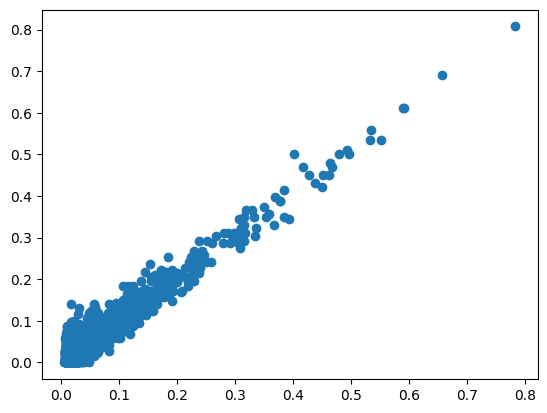

In [34]:
TMI = res_cor[:,0]
GMI = np.mean(res_cor[:,1:], axis=1)
RNL = 1 - GMI/TMI
plt.scatter(GMI,TMI)
RNL[GMI-TMI<0.1]=0
topp = np.argsort(RNL)[-6:]

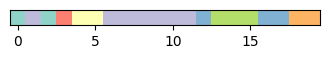

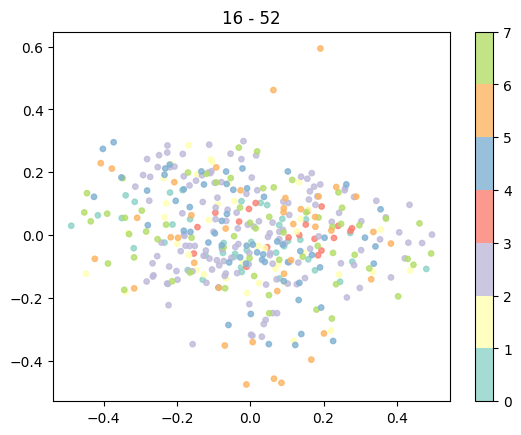

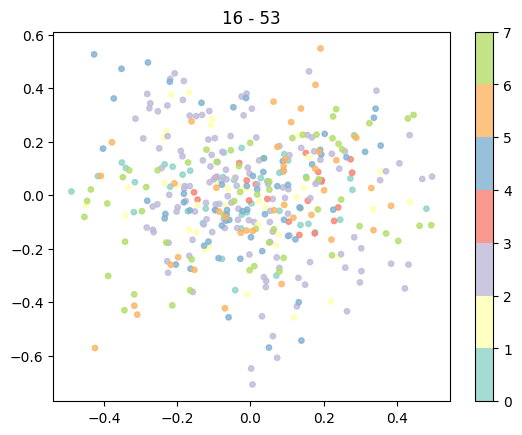

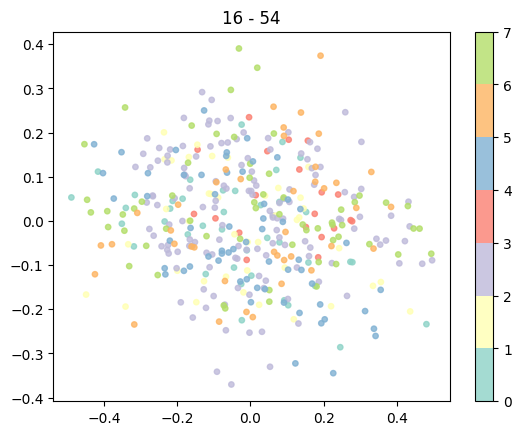

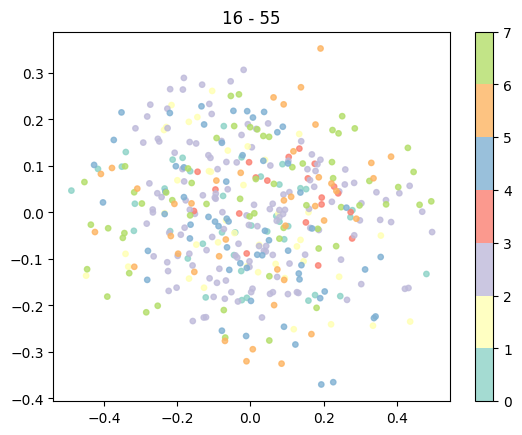

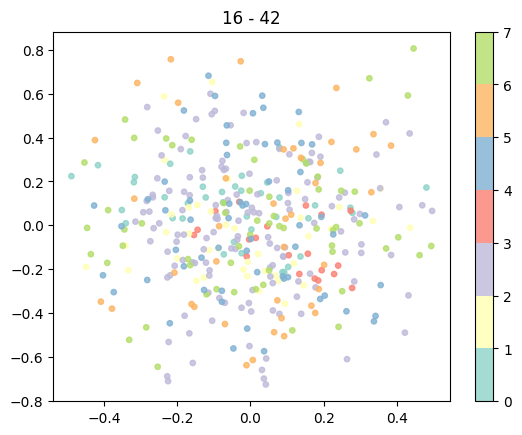

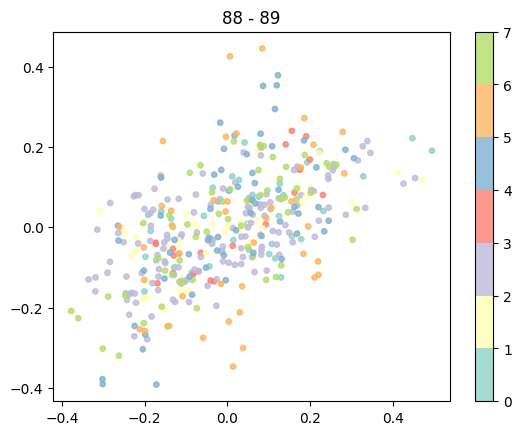

In [43]:
corr_plt = (int_corr[:,:] + int_corr[:,:].T)/2                         # made symmetric
np.fill_diagonal(corr_plt, 1)                        # put 1 on the diagonal
dissimilarity = 1 - np.abs(corr_plt)
hierarchy = linkage(squareform(dissimilarity), method='average')
labels = fcluster(hierarchy, 0.8, criterion='distance')
colors = np.repeat(labels,20)-1

plt.figure(figsize=(4,1))
plt.imshow(labels[np.newaxis, :]-1, cmap=plt.cm.Set3, norm=norm)
plt.yticks([])
plt.show()
for r1,r2 in np.array(np.triu_indices(reg_num,1))[:,topp].T:
    plt.scatter(mat[:,r1,TL],mat[:,r2,TL], c=colors,cmap=plt.cm.Set3, norm=norm, alpha=0.8, s=15)#plt.cm.Set3, alpha=0.7)
    plt.colorbar()
    plt.title(f"{r1} - {r2}")
    plt.show()